# 07 — Model Evaluation
## Paddy Yield Predictor

In [10]:

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "paddydataset.csv"

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.astype(str).str.strip()


In [11]:
import joblib
from sklearn.model_selection import train_test_split
TARGET='Paddy yield(in Kg)'; 
df=df.drop_duplicates().reset_index(drop=True); 
X=df.drop(columns=[TARGET]); y=df[TARGET]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)
model=joblib.load(Path.cwd().parent/'models'/'paddy_yield_predictor.pkl')
pred=model.predict(X_test)

In [12]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
metrics={'MAE':mean_absolute_error(y_test,pred),
         'MSE':mean_squared_error(y_test,pred),
         'RMSE':np.sqrt(mean_squared_error(y_test,pred)),
         'R2 Score':r2_score(y_test,pred)}
metrics_df=pd.DataFrame([metrics]); 
display(metrics_df)

from pathlib import Path

report_dir = Path.cwd().parent / "report"

report_dir.mkdir(parents=True, exist_ok=True)

metrics_df.to_csv(
    report_dir / "model_metrics.csv",
    index=False
)

print(f"Metrics saved successfully at: {report_dir / 'model_metrics.csv'}")
metrics_df.to_csv(Path.cwd().parent/'report'/'model_metrics.csv',index=False)

,MAE,MSE,RMSE,R2 Score
0,673.840158,872650.152636,934.157456,0.989807


Metrics saved successfully at: d:\TRUPTIMAYEE KHUNTIA\PADDY YIELD PREDICTOR\paddy_project\report\model_metrics.csv


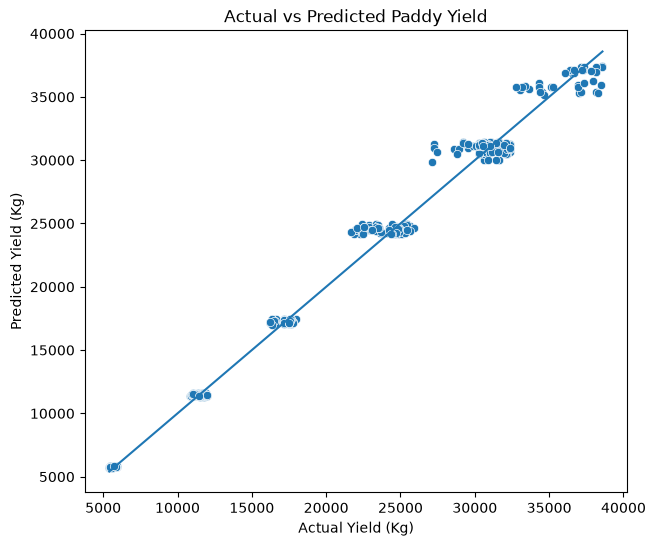

In [13]:
plt.figure(figsize=(7,6)); 
sns.scatterplot(x=y_test,y=pred);
plt.xlabel('Actual Yield (Kg)'); 
plt.ylabel('Predicted Yield (Kg)'); 
plt.title('Actual vs Predicted Paddy Yield');
lims=[min(y_test.min(),
          pred.min()),
          max(y_test.max(),
              pred.max())]; 
plt.plot(lims,lims); plt.show()

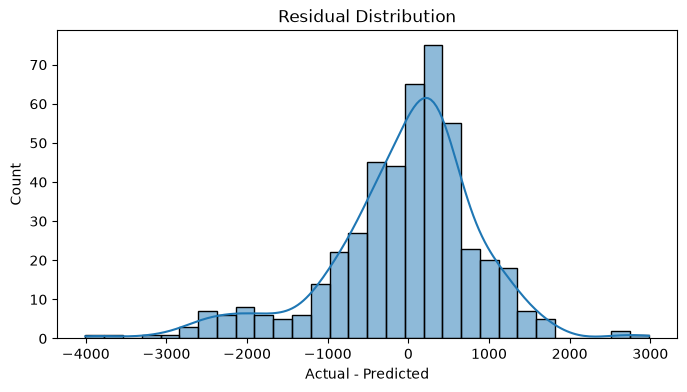

In [14]:
residuals=y_test-pred
plt.figure(figsize=(8,4)); 
sns.histplot(residuals,kde=True); 
plt.title('Residual Distribution'); 
plt.xlabel('Actual - Predicted'); 
plt.show()